In [1]:
import os, sys, pickle
%pylab inline
from importlib import reload
import pandas as pd
plt.style.use('default')
plt.rcParams['figure.figsize'] = (8, 3)
from tqdm import tqdm
from copy import deepcopy

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


In [2]:
git_path = os.getenv("GIT")
proj_path = os.path.join(git_path, "glom-io-transform-release")
sys.path.append(proj_path)
os.chdir(proj_path + "/model-fitting")
os.getcwd()
os.environ["GLOM_IO"] = proj_path
os.environ["GLOM_IO_DATA"] = proj_path + "/data"

In [3]:
assert "GLOM_IO" in os.environ, "GLOM_IO environment variable not set"
proj_path = os.environ["GLOM_IO"]
assert os.path.exists(proj_path), f"Project path {proj_path} does not exist"
sys.path.append(proj_path)
sys.path.append(proj_path + "/model-fitting") 

In [4]:
import common

In [5]:
assert "GLOM_IO_DATA" in os.environ, "GLOM_IO_DATA environment variable not set"
data_root = os.environ["GLOM_IO_DATA"]
assert os.path.exists(data_root), f"Path {data_root} does not exist"
with open(os.path.join(data_root, "X0Y0_new.p"), "rb") as f:
    data = pickle.load(f)
    X0 = data["X0"]
    Y0 = data["Y0"]


In [6]:
Xtrain, Xtest, Xvld, *_ = common.split(X0)
Ytrain, Ytest, Yvld, *_ = common.split(Y0)

In [7]:
import proc_fit_models as pfm
reload(pfm)
# model_train = copy(models)
import driver
reload(driver)
from driver import RunResults

### Load the fitted models

In [80]:
loaded_models = {}

In [81]:
proj_path

'/camp/home/tootoos/working/tootoos/git/glom-io-transform-release'

In [82]:
import layout
reload(pfm)
standardization = "separate"
normalization   = "odour_std"
center          = True
sampler         = "trials"
mode            = "random"
n_od_train      = "max"
base_dir = layout.build_fit_dir(name="FOOBAR",
    root = os.path.join(proj_path, "model-fitting/fits"),
                                center = center,
                                standardization = standardization,
                                normalization   = normalization,
                                sampler_type    = sampler,
                                split_mode      = mode,
                                n_od_train      = n_od_train
                                )
base_dir = base_dir.replace("/FOOBAR", "")
assert os.path.exists(base_dir), f"Base directory {base_dir} does not exist"
print(f"{base_dir=}")

base_dir='/camp/home/tootoos/working/tootoos/git/glom-io-transform-release/model-fitting/fits/center=True/standardization=separate/normalization=odour_std/sampler=trials/mode=random/n_od_train=max'


In [83]:
loaded_models_path = os.path.join(base_dir, "loaded_models.p")
assert os.path.exists(loaded_models_path), f"Loaded models file {loaded_models_path} does not exist. Run driver.py --loadmodels first."
with open(loaded_models_path, "rb") as f:
    loaded_models[base_dir] = pickle.load(f)
models = loaded_models[base_dir]

In [84]:
len(models["Diag"]["df"]["λ"].unique())

27

In [85]:
print(base_dir)
out_file = os.path.join(base_dir, "ffree", "out.0.p")
assert os.path.exists(out_file), f"Output file {out_file} does not exist"
with open(out_file, "rb") as f:
    out = pickle.load(f)

/camp/home/tootoos/working/tootoos/git/glom-io-transform-release/model-fitting/fits/center=True/standardization=separate/normalization=odour_std/sampler=trials/mode=random/n_od_train=max


In [86]:
out["results"]["mdl.results"]

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 0.001418642015797785
        x: [-9.696e-02 -4.625e-02 ...  3.125e-02  1.136e+00]
      nit: 343
      jac: [ 2.081e-06  1.454e-06 ... -1.524e-07 -2.899e-07]
     nfev: 358
     njev: 358
 hess_inv: <21904x21904 LbfgsInvHessProduct with dtype=float64>

In [87]:
np.mean((r.Cstar - r.Cest)**2)/2

np.float64(0.18497937169196824)

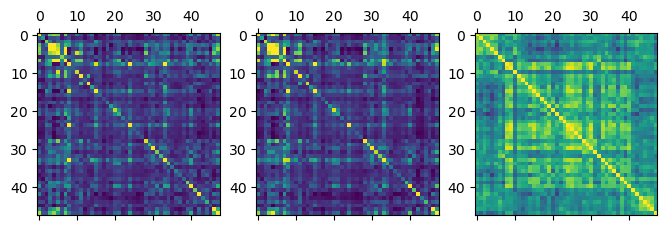

In [90]:
r = out["results"]["split"].trains[0]
from conn_models.common import compute_ratio
compute_ratio(r.Cstar, r.Cest, r.Cin)
fig, ax = plt.subplots(1, 3, figsize=(8, 3))
vlim = np.percentile(r.Cstar, [1, 99])
[axi.matshow(C, vmin=vlim[0], vmax=vlim[1]) for axi, C in zip(ax, [r.Cstar, r.Cest, r.Cin])
]

In [91]:
np.mean((r.Cstar - r.Cin)**2)/2

np.float64(0.08012485024045482)

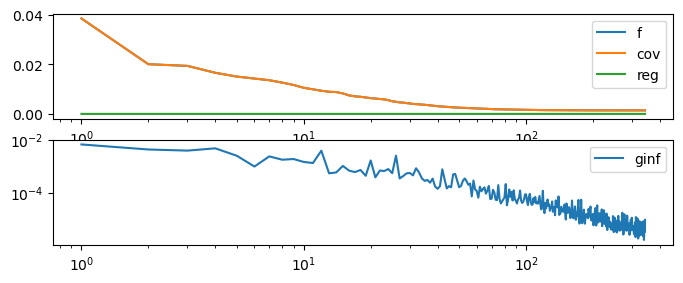

In [92]:
out["results"]["history"].keys()
def plot_history(history):
    it = history["it"]
    f  = history["f"]
    cov = history["cov"]
    reg = history["reg"]
    ginf = history["ginf"]
    subplot(2,1,1)
    semilogx(it, f, label="f")
    plot(it, cov, label="cov")
    plot(it, reg, label="reg")
    legend()
    subplot(2,1,2)
    loglog(it, ginf, label="ginf")
    legend()
plot_history(out["results"]["history"])

In [93]:
df = models["Free"]["df"]
df[(df.λ == 1e-3) & (df.seed == 0)]

,seed,split,ref,is_cross,file,sampler_type,mode,outclass,train_odours,test_odours,vld_odours,n_od_train,r2,pearson,spearman,ratio,λ
21210,0,trains,train[0],False,in.0.p,trials,random,None,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",(),(),48,0.945307,0.973305,0.942757,0.019799,0.001
21211,0,trains,train[1],False,in.0.p,trials,random,None,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",(),(),48,0.951343,0.975987,0.946575,0.019536,0.001
21212,0,trains,train[2],False,in.0.p,trials,random,None,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",(),(),48,0.945006,0.974455,0.944472,0.023324,0.001
21213,0,trains,train[3],False,in.0.p,trials,random,None,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",(),(),48,0.943369,0.972037,0.938070,0.020529,0.001
21214,0,trains,train[4],False,in.0.p,trials,random,None,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",(),(),48,0.947549,0.973609,0.943188,0.019913,0.001
21215,0,trains,train[5],False,in.0.p,trials,random,None,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",(),(),48,0.949077,0.975708,0.948788,0.018165,0.001
21216,0,trains,train[6],False,in.0.p,trials,random,None,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",(),(),48,0.957751,0.979586,0.937409,0.017131,0.001
21217,0,trains,train[7],False,in.0.p,trials,random,None,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",(),(),48,0.949763,0.977551,0.941925,0.021600,0.001
21218,0,trains,train[8],False,in.0.p,trials,random,None,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",(),(),48,0.962542,0.981207,0.952887,0.014050,0.001
21219,0,trains,train[9],False,in.0.p,trials,random,None,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",(),(),48,0.946366,0.976175,0.950203,0.018028,0.001


# # Process fitted models

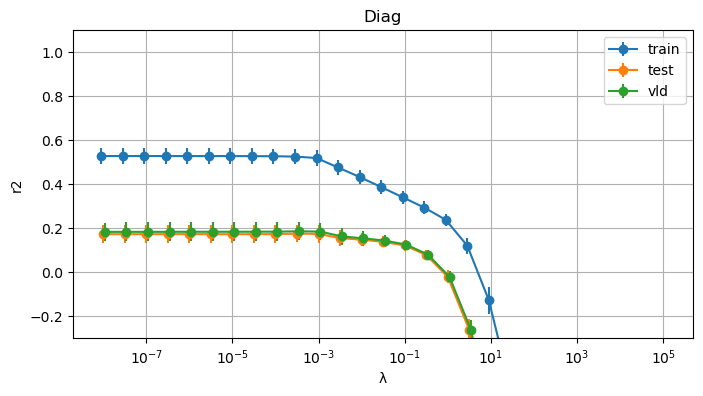

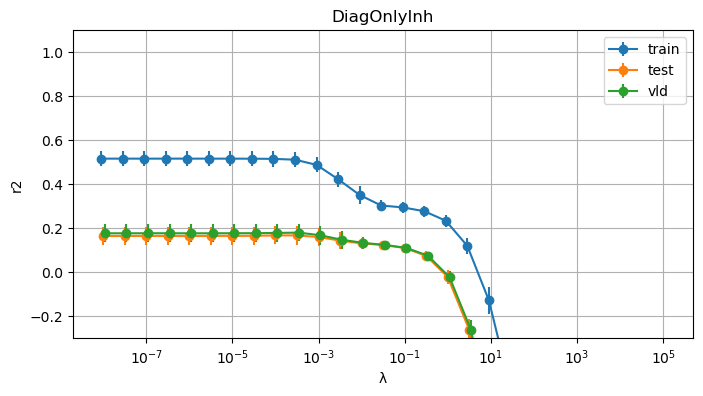

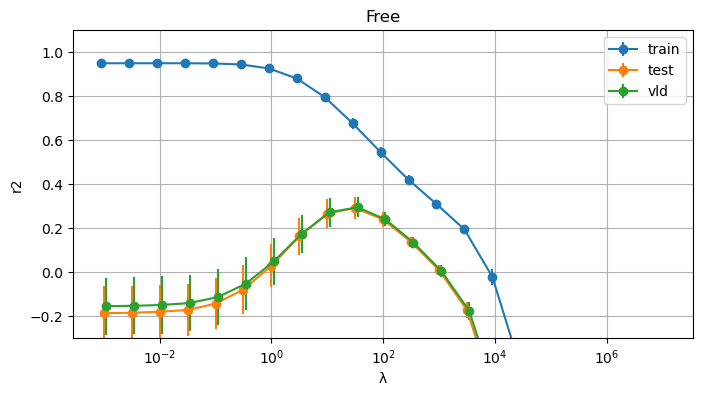

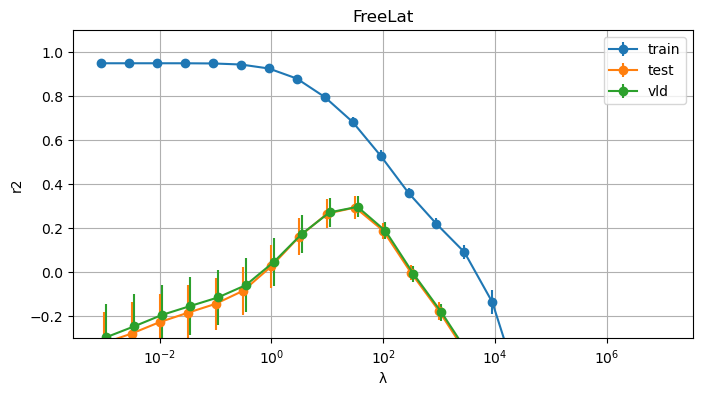

In [95]:
# For each model, count the number of parameters it has.
# If it has one parameter, plot the mean and std of the the ratio parameter for the train, test and vld sets.
subset_params = {}
stat = 'r2'
identity = lambda x: x
yl = (-0.3,1.1)
for name, mdl in sorted(models.items()):
#    if name not in ["Diag", "Free"]: #["Free", "FreeSym", "FreeAsym"]: #["Diag", "Diag101"]:
    #        continue
    # Copy mdl

    mdl = deepcopy(mdl)
    
    df = mdl["df"]
    descr = name 
    if name in subset_params:
        for k, v in subset_params[name].items():
            df = df[df[k] == v]
            # Remove k from the parameters
            print(f"Set {k}={v}. Removing from params list.")
            mdl["params"].remove(k)
            descr += f" {k}={v}"
            
    if len(mdl["params"]) == 2:
        p0, p1  = mdl["params"]
        p0_vals = np.unique(df[p0].values)
        p1_vals = np.unique(df[p1].values)
        vals    = np.zeros((3, len(p0_vals), len(p1_vals)))
        figure(figsize=(12,4))        
        # Fill a matrix called ratio_test with the mean of the ratio_test values using the sort order of the λ0 and λ1 values as indices
        for ifld, fld  in enumerate(['train', 'test','vld']):
            for i, v0 in enumerate(p0_vals):
                for j, v1 in enumerate(p1_vals):
                    # Group the rows of df by the two parameters and take the mean of the ratio_test column                    
                    vals[ifld, i, j] = df[(df[p0] == v0) & (df[p1] == v1)][f'{stat}_{fld}'].mean()
            
            subplot(1,3,ifld+1)
            # Plot the ratio_test values as a function of λ1 and λ2
            #vmin = max(0.5, vals[ifld].min())
            #vmax = min(1.5, vals[ifld].max())
            vmin, vmax = percentile(vals[ifld], [1, 99])
            vmin, vmax = max(vmin,0), min(vmax, 2)
            vmin, vmax = sorted([vmin, vmax])
            matshow(vals[ifld], cmap='Spectral_r', vmin = vmin, vmax = vmax, fignum=False); axis("auto"); colorbar()
            # Use the log10 of the λ values for the x and y ticks
            # Label using the :g format option to avoid scientific notation
            tform = lambda p: (identity if p[0] != 'λ' else log10)
            tname = lambda p: ("" if p[0] != 'λ' else "log10")
            yticks(range(len(p0_vals)), [f'{tform(p0)(p):g}' for p in p0_vals]); ylabel(f"{tname(p0)} {p0}")
            xticks(range(len(p1_vals)), [f'{tform(p1)(p):g}' for p in p1_vals]); xlabel(f"{tname(p1)} {p1}")
            title(f'{stat}_{fld} as a function of {p0} and {p1}', pad=1)
            tight_layout()
        suptitle(descr, y = 1.0)

    if len(mdl["params"]) == 1:
        param = mdl["params"][0]
        figure(figsize=(8, 4))
        for i, fld in enumerate(['train', 'test', 'vld']):
            mask = df["split"].str.startswith("train") if fld == "train" else df["split"] == fld
            sub = df[mask]
            stat_mean = sub.groupby(param)[stat].mean()
            stat_std  = sub.groupby(param)[stat].std()
            if mdl["params"][0] == "λ":
                # Use a log scale for the x-axis
                plt.xscale('log')
            # Stagger the x-values for the train, test, and validation sets
            errorbar(stat_mean.index * (0.9+i/10), stat_mean, yerr=stat_std, label=fld, marker='o')
        xlabel(param)
        ylabel(f'{stat}')
        if yl is None:
            yl = list(ylim()) 
            yl[0] = max(yl[0], 0)
            yl[1] = min(yl[1], 2)       
        ylim(yl)
        legend()
        title(descr)
        grid(True)
#xlim(9,1100)

In [33]:
stat = 'r2'
for name, mdl in models.items():
    # if name not in ["Diag", "Diag101"]: continue
    params = mdl["params"]
    df     = mdl["df"]
    # For each setting of the parameters, compute the mean of the ratio_test values
    # Store the parameter values that gave the lowest ratio in best_params
    # Store the lowest ratio in best_stats
    stat_mean = df.groupby(params)[f'{stat}_test'].mean()
    best_params = stat_mean.idxmin() if stat == 'ratio' else stat_mean.idxmax()
    # For each of train, test, and vld, compute the mean and std of the ratio values at the best_params
    best_means = {}
    best_stds  = {}
    for set_name in ['train', 'test', 'vld']:
        if len(params) == 1:
            df_sub = df[df[params[0]] == best_params]
        elif len(params) == 2:
            df_sub = df[(df[params[0]] == best_params[0]) & (df[params[1]] == best_params[1])]

        best_means[set_name] = df_sub[f'{stat}_{set_name}'].mean()
        best_stds[set_name]  = df_sub[f'{stat}_{set_name}'].std()

    models[name]["best_params"] = best_params
    models[name]["best_means"]  = best_means
    models[name]["best_stds"]   = best_stds    

Text(0, 0.5, 'r2 for the validation set')

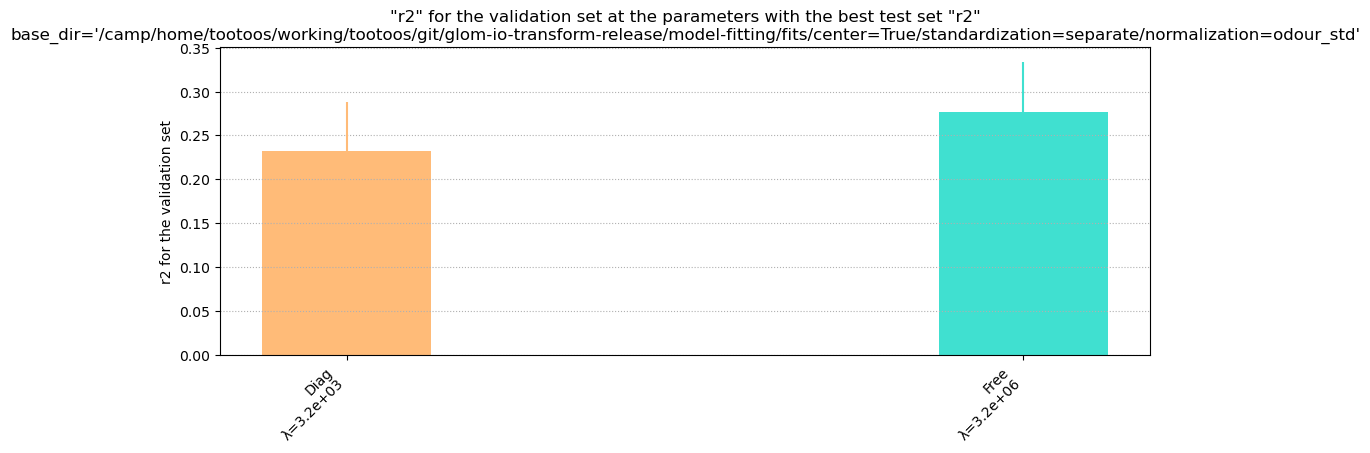

In [36]:
# Plot a bar chart showing the best_means for the vld set for each model
# Add error bars showing the best_stds for the vld set for each model
# Use the model names as the x-ticks
# Order the models by the best_means for the vld set
bar_width = 0.25
figure(figsize=(12, 4))
# Sort the models by the best_means for the vld set
sorted_models = sorted(models.items(), key=lambda x: x[1]["best_means"][f"vld"])
# Plot the best_means for the vld set for each model
# Give each bar a different color
param_strs = {}
for i, (name, mdl) in enumerate(sorted_models):
    best_means = mdl["best_means"]
    best_stds  = mdl["best_stds"]
    col = pfm.model_color(name)
    # Set the error-bar color to be the same as the bar color    
    bar(i, best_means["vld"], yerr=best_stds["vld"], width=bar_width, label=name, color=col, error_kw={"ecolor": col})
    if len(mdl["params"]) == 1:
        param_strs[name] = f'{mdl["params"][0]}={mdl["best_params"]:.2g}'
    elif len(mdl["params"]) > 1:
        param_strs[name] = ", ".join([f'{p}={v:.2g}' for p, v in zip(mdl["params"], mdl["best_params"])])
# Plot a horizontal line at 1.0

# Set the x-ticks to be the model names and the parameters that gave the best_means for the vld set
xticks(range(len(models)), [f'{name}\n{param_strs[name]}' for name, mdl in sorted_models], rotation=45, ha='right')    
#xticks(range(len(models)), [name for name, mdl in sorted_models], rotation=45, ha='right')
#ylim(0.8,1.25)
grid(True, which='both', axis='y', linestyle=':')
title(f'"{stat}" for the validation set at the parameters with the best test set "{stat}"\n{base_dir=}')
ylabel(f'{stat} for the validation set')